# Metrics Calculation for Diffusion LLMs Evaluation

This notebook computes evaluation metrics by comparing model outputs against human-annotated ground truth across 5 metrics and 7 models.

Each metric section is self-contained — run cells sequentially.

In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error,
)
from scipy.stats import spearmanr, pearsonr
# base should be one level above
BASE = Path("/Users/lokovacic/Projects/diffusion-llms-eval")
RESULTS_DIR = BASE / "results"
DATASETS_DIR = BASE / "datasets" / "final_datasets"

# All model result directories
EXCLUDE_MODELS = {"archive"}
MODEL_DIRS = sorted(
    d for d in RESULTS_DIR.iterdir()
    if d.is_dir() and d.name not in EXCLUDE_MODELS
)
print(f"Found {len(MODEL_DIRS)} models:")
for m in MODEL_DIRS:
    print(f"  {m.name}")

Found 7 models:
  LLaDA2.1-mini
  Qwen3.6-35B-A3B-FP8
  gemma-4-26b-a4b-it
  gemma-4-31b-it
  gemma-4-e2b-it
  gpt-4.1-mini
  qwen35-2b


---
## Helper Functions

In [2]:
def find_result_file(model_dir: Path, pattern: str) -> Path | None:
    files = list(model_dir.glob(pattern))
    return files[0] if files else None

def load_model_results_csv(model_dir: Path, metric_name: str) -> pd.DataFrame:
    csv_pat = f"*_{metric_name}-test_results.csv"
    path = find_result_file(model_dir, csv_pat)
    if path is None:
        return None
    return pd.read_csv(path)

def load_model_details_json(model_dir: Path, metric_name: str) -> dict | None:
    json_pat = f"*_{metric_name}-test_details.json"
    path = find_result_file(model_dir, json_pat)
    if path is None:
        return None
    with open(path) as f:
        return json.load(f)

def collect_all_results(model_dirs, metric_name, score_col):
    dfs = {}
    for md in model_dirs:
        df = load_model_results_csv(md, metric_name)
        if df is not None and score_col in df.columns:
            df = df[['case_id', score_col]].copy()
            dfs[md.name] = df.set_index('case_id')[score_col]
    return pd.DataFrame(dfs)

def report_continuous(name, golden, predicted):
    valid = golden.notna() & predicted.notna()
    g, p = golden[valid], predicted[valid]
    if len(g) < 2:
        return {f"{name}_mae": None, f"{name}_pearson_r": None, f"{name}_spearman_rho": None}
    from sklearn.metrics import mean_absolute_error
    from scipy.stats import pearsonr, spearmanr
    mae = mean_absolute_error(g, p)
    pr, _ = pearsonr(g, p)
    sr, _ = spearmanr(g, p)
    return {f"{name}_mae": mae, f"{name}_pearson_r": pr, f"{name}_spearman_rho": sr}

def report_binary(name, golden, predicted):
    from sklearn.metrics import accuracy_score, f1_score
    valid = golden.notna() & predicted.notna()
    g, p = golden[valid].astype(int), predicted[valid].astype(int)
    if len(g) == 0:
        return {f"{name}_accuracy": None, f"{name}_f1": None}
    acc = accuracy_score(g, p)
    f1 = f1_score(g, p, average='binary', zero_division=0)
    return {f"{name}_accuracy": acc, f"{name}_f1": f1}

def report_ordinal(name, golden, predicted, labels=None, weights='quadratic'):
    from sklearn.metrics import accuracy_score, cohen_kappa_score
    valid = golden.notna() & predicted.notna()
    g, p = golden[valid].astype(int), predicted[valid].astype(int)
    if len(g) == 0:
        return {f"{name}_exact_accuracy": None, f"{name}_cohen_kappa": None}
    acc = accuracy_score(g, p)
    kappa = cohen_kappa_score(g, p, labels=labels, weights=weights)
    return {f"{name}_exact_accuracy": acc, f"{name}_cohen_kappa": kappa}

def safe_cohen_kappa_quadratic(y1, y2):
    from sklearn.metrics import cohen_kappa_score
    mask = y1.notna() & y2.notna()
    if mask.sum() < 2:
        return None
    return cohen_kappa_score(y1[mask].astype(int), y2[mask].astype(int), weights='quadratic')

---
## 1. Answer Relevancy

**Continuous score**: model-predicted cosine similarity vs golden cosine similarity.

**Noncommittal flag**: binary classification of whether model correctly refused to answer.

In [3]:
# --- Load ground truth ---
ar_golden = pd.read_csv(DATASETS_DIR / "answer_relevancy-test-annotated.csv")
ar_golden = ar_golden[['case_id', 'uncommittal', 'golden_cosine_similarity']].copy()
ar_golden = ar_golden.set_index('case_id')
print(f"Golden cases: {len(ar_golden)}")
print(f"Uncommittal cases: {ar_golden['uncommittal'].sum()}")

Golden cases: 30
Uncommittal cases: 10


In [4]:
# --- Load model results ---
ar_scores = collect_all_results(MODEL_DIRS, "answer-relevancy", "answer_relevancy")
print(f"Models with answer_relevancy results: {list(ar_scores.columns)}")

# Join with golden
ar_results = ar_golden.join(ar_scores, how='inner')
print(f"Merged rows: {len(ar_results)}")

Models with answer_relevancy results: ['LLaDA2.1-mini', 'Qwen3.6-35B-A3B-FP8', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemma-4-e2b-it', 'gpt-4.1-mini', 'qwen35-2b']
Merged rows: 30


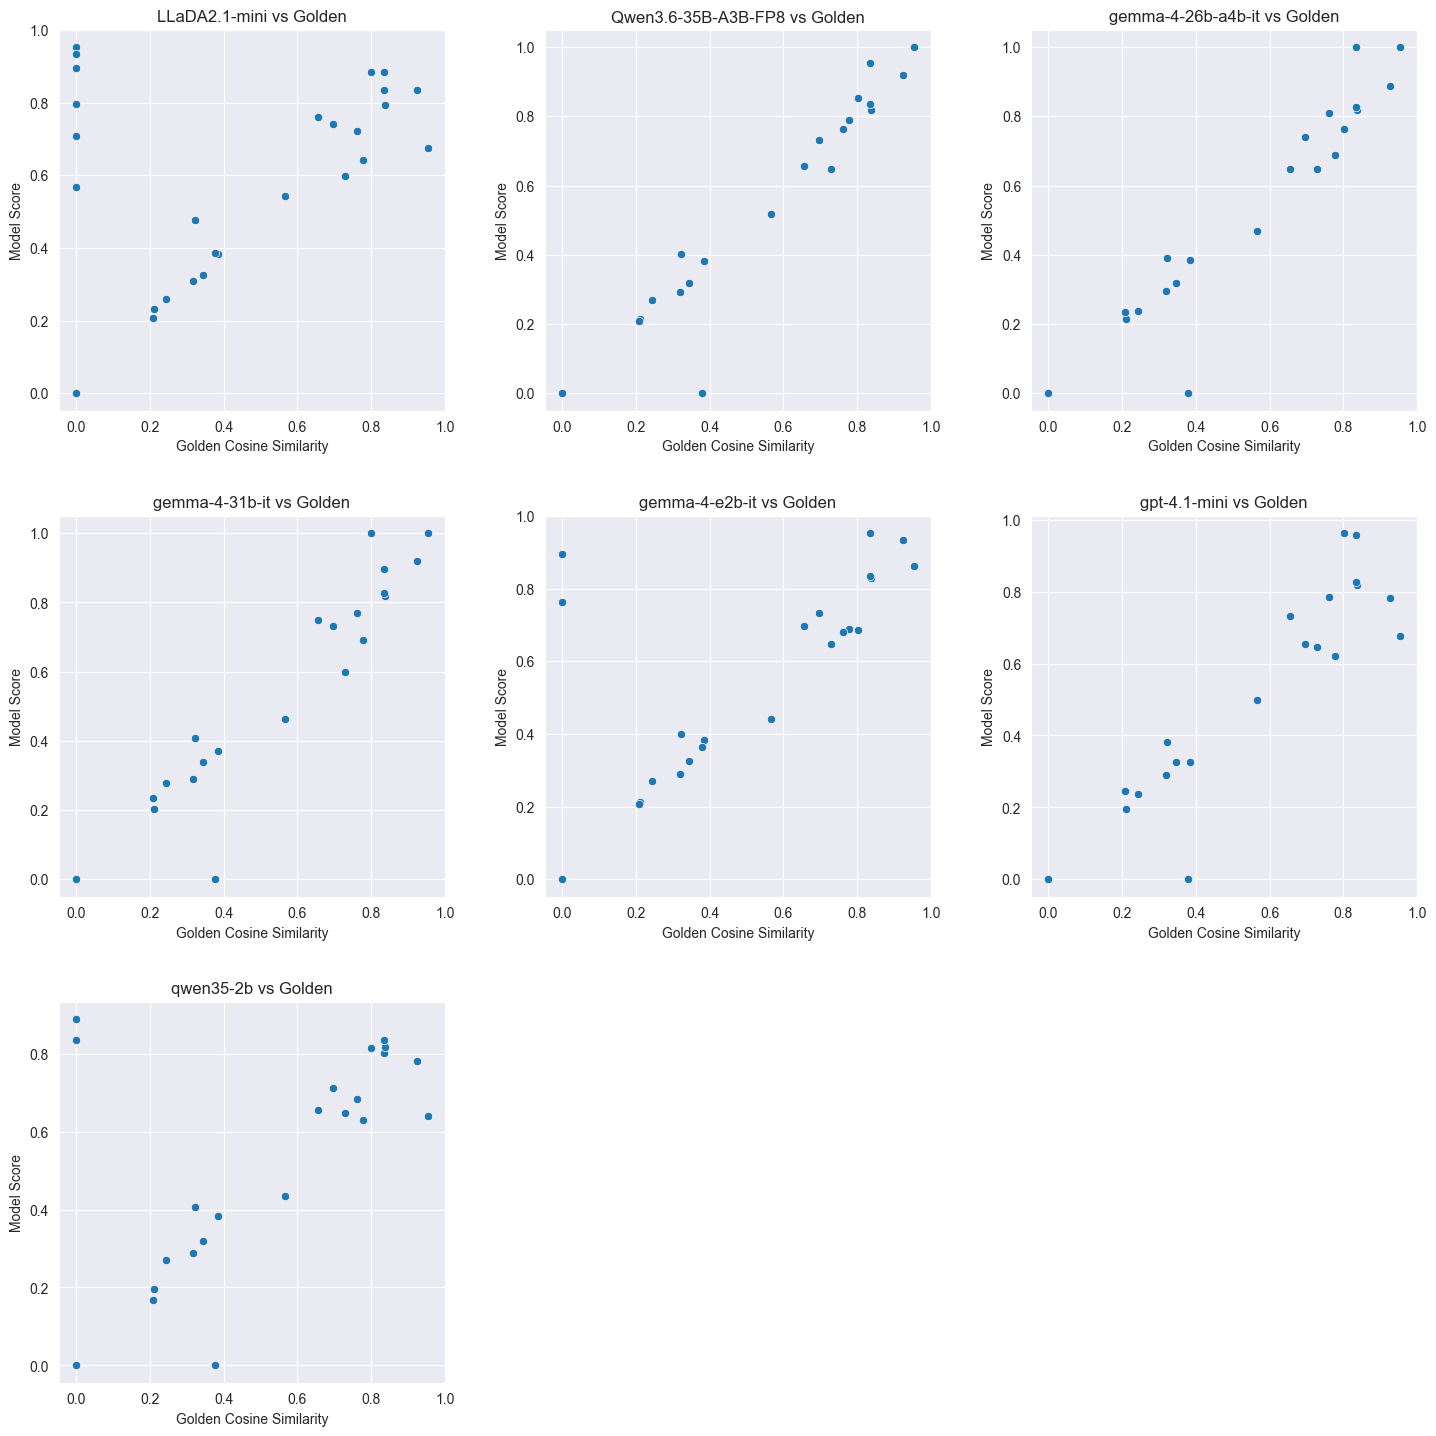

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 15))

for i, model in enumerate(ar_scores.columns):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(
        x=ar_results['golden_cosine_similarity'],
        y=ar_results[model]
    )
    plt.title(f"{model} vs Golden")
    plt.xlabel("Golden Cosine Similarity")
    plt.ylabel("Model Score")

plt.tight_layout(pad=3.0)
plt.show()

In [6]:
# --- Compute metrics ---
ar_rows = []
for model in ar_scores.columns:
    row = {'model': model}
    
    # Continuous score: golden cosine similarity vs model score
    cont = report_continuous('score', ar_results['golden_cosine_similarity'], ar_results[model])
    row.update(cont)
    
    # Noncommittal flag: binary
    predicted_uncommittal = (ar_results[model] == 0.0).astype(int)
    bin_ = report_binary('noncommittal', ar_results['uncommittal'], predicted_uncommittal)
    row.update(bin_)
    
    # Also weighted and macro F1 for noncommittal
    valid = ar_results['uncommittal'].notna() & predicted_uncommittal.notna()
    g, p = ar_results.loc[valid, 'uncommittal'].astype(int), predicted_uncommittal[valid].astype(int)
    if len(g) > 0:
        row['noncommittal_weighted_f1'] = f1_score(g, p, average='weighted', zero_division=0)
        row['noncommittal_macro_f1'] = f1_score(g, p, average='macro', zero_division=0)
    else:
        row['noncommittal_weighted_f1'] = None
        row['noncommittal_macro_f1'] = None
    
    ar_rows.append(row)

ar_metrics = pd.DataFrame(ar_rows).set_index('model')
ar_metrics

,score_mae,score_pearson_r,score_spearman_rho,noncommittal_accuracy,noncommittal_f1,noncommittal_weighted_f1,noncommittal_macro_f1
model,,,,,,,
LLaDA2.1-mini,0.234764,0.345875,0.197516,0.766667,0.461538,0.721222,0.656301
Qwen3.6-35B-A3B-FP8,0.032152,0.976876,0.961089,0.966667,0.952381,0.967033,0.963370
gemma-4-26b-a4b-it,0.040559,0.972587,0.958300,0.966667,0.952381,0.967033,0.963370
gemma-4-31b-it,0.046028,0.968710,0.955511,0.966667,0.952381,0.967033,0.963370
gemma-4-e2b-it,0.087472,0.798442,0.768137,0.933333,0.888889,0.931217,0.920635
gpt-4.1-mini,0.059447,0.955763,0.933197,0.966667,0.952381,0.967033,0.963370
qwen35-2b,0.110212,0.736994,0.661468,0.900000,0.842105,0.898588,0.884467


In [7]:
# Compute metrics with only committal answers

ar_committal = ar_results[ar_results['uncommittal'] == 0.0]
# --- Compute metrics ---
ar_rows = []
for model in ar_scores.columns:
    row = {'model': model}

    # Continuous score: golden cosine similarity vs model score
    cont = report_continuous('score', ar_committal['golden_cosine_similarity'], ar_committal[model])
    row.update(cont)

    # Noncommittal flag: binary
    predicted_uncommittal = (ar_committal[model] == 0.0).astype(int)
    bin_ = report_binary('noncommittal', ar_committal['uncommittal'], predicted_uncommittal)
    row.update(bin_)

    # Also weighted and macro F1 for noncommittal
    valid = ar_committal['uncommittal'].notna() & predicted_uncommittal.notna()
    g, p = ar_committal.loc[valid, 'uncommittal'].astype(int), predicted_uncommittal[valid].astype(int)
    if len(g) > 0:
        row['noncommittal_weighted_f1'] = f1_score(g, p, average='weighted', zero_division=0)
        row['noncommittal_macro_f1'] = f1_score(g, p, average='macro', zero_division=0)
    else:
        row['noncommittal_weighted_f1'] = None
        row['noncommittal_macro_f1'] = None

    ar_rows.append(row)

ar_metrics = pd.DataFrame(ar_rows).set_index('model')
ar_metrics

,score_mae,score_pearson_r,score_spearman_rho,noncommittal_accuracy,noncommittal_f1,noncommittal_weighted_f1,noncommittal_macro_f1
model,,,,,,,
LLaDA2.1-mini,0.062805,0.932123,0.873684,1.00,0.0,1.000000,1.000000
Qwen3.6-35B-A3B-FP8,0.048227,0.947822,0.939850,0.95,0.0,0.974359,0.487179
gemma-4-26b-a4b-it,0.060838,0.937798,0.930827,0.95,0.0,0.974359,0.487179
gemma-4-31b-it,0.069043,0.928195,0.921805,0.95,0.0,0.974359,0.487179
gemma-4-e2b-it,0.048185,0.969019,0.935338,1.00,0.0,1.000000,1.000000
gpt-4.1-mini,0.089171,0.892877,0.849624,0.95,0.0,0.974359,0.487179
qwen35-2b,0.079191,0.903758,0.848120,0.95,0.0,0.974359,0.487179


---
## 2. Context Relevance

**Combined score** (ordinal: 0, 0.25, 0.5, 0.75, 1): MAE, Spearman ρ, Exact-match accuracy, Cohen's κ (quadratic).

**Per-judge rating** (3-class: 0, 1, 2): Weighted F1 (macro), Cohen's κ (quadratic).

Note: annotated CSV has a single `rating` (0/1/2) per case. Model produces 2 judges. We compare the golden rating against both judges.

In [8]:
# --- Load ground truth ---

cr_golden = pd.read_csv(DATASETS_DIR / "context-relevance-test-annotated.csv")
cr_golden = cr_golden.set_index('case_id')
cr_golden['combined_golden'] = cr_golden['rating'] / 2
cr_golden

,question,prompt,rating,combined_golden
case_id,,,,
CR1,What is LLM-as-a-judge?,You are a world class expert designed to evalu...,2,1.0
CR2,What is agent observability?,You are a world class expert designed to evalu...,2,1.0
CR3,What is AI observability?,You are a world class expert designed to evalu...,2,1.0
CR4,How do I deploy a LangGraph agent to production?,You are a world class expert designed to evalu...,0,0.0
CR5,What programming languages does LangChain supp...,You are a world class expert designed to evalu...,0,0.0
CR6,How do I set up webhook notifications in LangS...,You are a world class expert designed to evalu...,0,0.0
CR7,How do I build a custom LLM-as-a-judge evaluat...,You are a world class expert designed to evalu...,1,0.5
CR8,What Python code do I need to add trajectory e...,You are a world class expert designed to evalu...,1,0.5
CR9,How do I implement offline updates to the cont...,You are a world class expert designed to evalu...,1,0.5


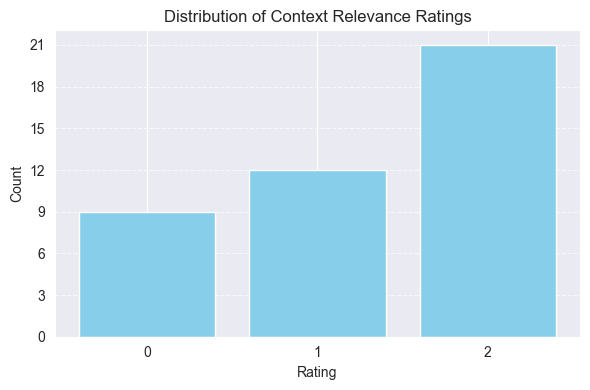

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(6, 4))

rating_counts = cr_golden['rating'].value_counts().sort_index()

plt.bar(rating_counts.index, rating_counts.values, color='skyblue')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Context Relevance Ratings')
plt.xticks(rating_counts.index)

plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# --- Load model results ---
cr_combined = collect_all_results(MODEL_DIRS, "context-relevance", "context_relevance")
print(f"Models with CR combined results: {list(cr_combined.columns)}")

# --- Load model per-judge ratings from details JSON ---
cr_judge_rows = []
for md in MODEL_DIRS:
    details = load_model_details_json(md, "context-relevance")
    if details is None:
        continue
    for t in details['traces']:
        cr_judge_rows.append({
            'model': md.name,
            'case_id': t['case_id'],
            'judge1': t['judge1_rating'],
            'judge2': t['judge2_rating'],
        })
cr_judges = pd.DataFrame(cr_judge_rows).set_index(['model', 'case_id'])
print(f"Loaded per-judge ratings: {len(cr_judges)} rows")


Models with CR combined results: ['LLaDA2.1-mini', 'Qwen3.6-35B-A3B-FP8', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemma-4-e2b-it', 'gpt-4.1-mini', 'qwen35-2b']
Loaded per-judge ratings: 294 rows


In [11]:
# lets join the golden ratings with cr_judges so we have it in the same df
cr_judges_to_csv = cr_judges.copy()
cr_judges_to_csv = cr_judges_to_csv.join(cr_golden[['rating']], how='inner')
cr_judges_to_csv.rename(columns={'rating': 'golden_rating'}, inplace=True)
cr_judges_to_csv.to_csv(BASE / "results" / "context_relevance_per_judge_ratings.csv")

In [12]:
cr_rows = []
for model in cr_combined.columns:
    row = {'model': model}
    
    # Combined score (from results CSV)
    combined = cr_combined[model]
    cont = report_continuous('combined', cr_golden['combined_golden'], combined)
    ord_ = report_ordinal('combined', cr_golden['combined_golden'] * 4, combined * 4, weights='quadratic')
    row.update(cont)
    row.update(ord_)
    
    # Per-judge: golden rating vs judge1 and judge2
    if model in cr_judges.index.get_level_values('model'):
        jdf = cr_judges.loc[model].copy()
        jdf = jdf.join(cr_golden[['rating']], how='inner')
        
        # Filter NaN before computing metrics
        j1_valid = jdf['judge1'].notna() & jdf['rating'].notna()
        j2_valid = jdf['judge2'].notna() & jdf['rating'].notna()
        
        if j1_valid.sum() >= 2:
            j1_kappa = safe_cohen_kappa_quadratic(jdf['rating'], jdf['judge1'])
            j1_wf1 = f1_score(jdf.loc[j1_valid, 'rating'].astype(int), jdf.loc[j1_valid, 'judge1'].astype(int), average='weighted', zero_division=0)
        else:
            j1_kappa = None
            j1_wf1 = None
        row['judge1_cohen_kappa'] = j1_kappa
        row['judge1_weighted_f1'] = j1_wf1
        
        if j2_valid.sum() >= 2:
            j2_kappa = safe_cohen_kappa_quadratic(jdf['rating'], jdf['judge2'])
            j2_wf1 = f1_score(jdf.loc[j2_valid, 'rating'].astype(int), jdf.loc[j2_valid, 'judge2'].astype(int), average='weighted', zero_division=0)
        else:
            j2_kappa = None
            j2_wf1 = None
        row['judge2_cohen_kappa'] = j2_kappa
        row['judge2_weighted_f1'] = j2_wf1
        
        # Average (only if both available)
        if j1_kappa is not None and j2_kappa is not None:
            row['avg_judge_cohen_kappa'] = (j1_kappa + j2_kappa) / 2
            row['avg_judge_weighted_f1'] = (j1_wf1 + j2_wf1) / 2
        else:
            row['avg_judge_cohen_kappa'] = None
            row['avg_judge_weighted_f1'] = None
    
    cr_rows.append(row)

cr_metrics = pd.DataFrame(cr_rows).set_index('model')
cr_metrics

,combined_mae,combined_pearson_r,combined_spearman_rho,combined_exact_accuracy,combined_cohen_kappa,judge1_cohen_kappa,judge1_weighted_f1,judge2_cohen_kappa,judge2_weighted_f1,avg_judge_cohen_kappa,avg_judge_weighted_f1
model,,,,,,,,,,,
LLaDA2.1-mini,0.130952,0.771565,0.764987,0.738095,0.759236,0.678899,0.710559,0.660793,0.675336,0.669846,0.692947
Qwen3.6-35B-A3B-FP8,0.053571,0.946944,0.960200,0.857143,0.935858,0.930348,0.905245,0.918033,0.878228,0.924191,0.891736
gemma-4-26b-a4b-it,0.029762,0.961944,0.964380,0.928571,0.949214,0.963158,0.952717,0.946292,0.929109,0.954725,0.940913
gemma-4-31b-it,0.083333,0.918589,0.940968,0.809524,0.831414,0.887356,0.828970,0.887356,0.828970,0.887356,0.828970
gemma-4-e2b-it,0.136905,0.867327,0.857407,0.595238,0.804823,0.737968,0.714484,0.770149,0.718436,0.754059,0.716460
gpt-4.1-mini,0.059524,0.934794,0.934780,0.809524,0.934754,0.927461,0.901890,0.891192,0.853360,0.909326,0.877625
qwen35-2b,0.196429,0.726753,0.689867,0.523810,0.712845,0.680965,0.671921,0.686567,0.556677,0.683766,0.614299


---
## 3. Response Groundedness

**Combined score** (ordinal: 0, 0.25, 0.5, 0.75, 1): MAE, Spearman ρ, Exact-match accuracy, Cohen's κ (quadratic).

**Per-judge rating** (3-class: 0, 1, 2): Weighted F1 (macro), Cohen's κ (quadratic).

Note: annotated CSV has a single `rating` (0/1/2) per case. Model produces 2 judges. We compare the golden rating against both judges.

In [13]:
# --- Load ground truth ---
rg_golden = pd.read_csv(DATASETS_DIR / "response-groundedness-test-annotated.csv")
rg_golden = rg_golden[['case_id', 'rating']].copy()
rg_golden = rg_golden.set_index('case_id')
rg_golden['combined_golden'] = rg_golden['rating'] / 2.0
print(f"RG golden cases: {len(rg_golden)}")
print(f"Rating distribution:\n{rg_golden['rating'].value_counts().sort_index()}")

RG golden cases: 47
Rating distribution:
rating
0    15
1    20
2    12
Name: count, dtype: int64


In [14]:
# --- Load model results ---
rg_combined = collect_all_results(MODEL_DIRS, "response-groundedness", "response_groundedness")
print(f"Models with RG combined results: {list(rg_combined.columns)}")

# --- Load per-judge ratings from details JSON ---
rg_judge_rows = []
for md in MODEL_DIRS:
    details = load_model_details_json(md, "response-groundedness")
    if details is None:
        continue
    for t in details['traces']:
        rg_judge_rows.append({
            'model': md.name,
            'case_id': t['case_id'],
            'judge1': t['judge1_rating'],
            'judge2': t['judge2_rating'],
        })
rg_judges = pd.DataFrame(rg_judge_rows).set_index(['model', 'case_id'])
print(f"Loaded per-judge ratings: {len(rg_judges)} rows")

Models with RG combined results: ['LLaDA2.1-mini', 'Qwen3.6-35B-A3B-FP8', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemma-4-e2b-it', 'gpt-4.1-mini', 'qwen35-2b']
Loaded per-judge ratings: 329 rows


In [15]:
# lets join the golden ratings with cr_judges so we have it in the same df
rg_judges_to_csv = rg_judges.copy()
rg_judges_to_csv = rg_judges_to_csv.join(rg_golden[['rating']], how='inner')
rg_judges_to_csv.rename(columns={'rating': 'golden_rating'}, inplace=True)
rg_judges_to_csv.to_csv(BASE / "results" / "response_groundedness_per_judge_ratings.csv")

In [16]:
rg_rows = []
for model in rg_combined.columns:
    row = {'model': model}
    
    # Combined score
    combined = rg_combined[model]
    cont = report_continuous('combined', rg_golden['combined_golden'], combined)
    ord_ = report_ordinal('combined', rg_golden['combined_golden'] * 4, combined * 4, weights='quadratic')
    row.update(cont)
    row.update(ord_)
    
    # Per-judge
    if model in rg_judges.index.get_level_values('model'):
        jdf = rg_judges.loc[model].copy()
        jdf = jdf.join(rg_golden[['rating']], how='inner')
        
        j1_valid = jdf['judge1'].notna() & jdf['rating'].notna()
        j2_valid = jdf['judge2'].notna() & jdf['rating'].notna()
        
        if j1_valid.sum() >= 2:
            j1_kappa = safe_cohen_kappa_quadratic(jdf['rating'], jdf['judge1'])
            j1_wf1 = f1_score(jdf.loc[j1_valid, 'rating'].astype(int), jdf.loc[j1_valid, 'judge1'].astype(int), average='weighted', zero_division=0)
        else:
            j1_kappa = None
            j1_wf1 = None
        row['judge1_cohen_kappa'] = j1_kappa
        row['judge1_weighted_f1'] = j1_wf1
        
        if j2_valid.sum() >= 2:
            j2_kappa = safe_cohen_kappa_quadratic(jdf['rating'], jdf['judge2'])
            j2_wf1 = f1_score(jdf.loc[j2_valid, 'rating'].astype(int), jdf.loc[j2_valid, 'judge2'].astype(int), average='weighted', zero_division=0)
        else:
            j2_kappa = None
            j2_wf1 = None
        row['judge2_cohen_kappa'] = j2_kappa
        row['judge2_weighted_f1'] = j2_wf1
        
        if j1_kappa is not None and j2_kappa is not None:
            row['avg_judge_cohen_kappa'] = (j1_kappa + j2_kappa) / 2
            row['avg_judge_weighted_f1'] = (j1_wf1 + j2_wf1) / 2
        else:
            row['avg_judge_cohen_kappa'] = None
            row['avg_judge_weighted_f1'] = None
    
    rg_rows.append(row)

rg_metrics = pd.DataFrame(rg_rows).set_index('model')
rg_metrics

,combined_mae,combined_pearson_r,combined_spearman_rho,combined_exact_accuracy,combined_cohen_kappa,judge1_cohen_kappa,judge1_weighted_f1,judge2_cohen_kappa,judge2_weighted_f1,avg_judge_cohen_kappa,avg_judge_weighted_f1
model,,,,,,,,,,,
LLaDA2.1-mini,0.324468,0.452341,0.462385,0.425532,0.417310,0.421083,0.387529,0.348354,0.364814,0.384718,0.376172
Qwen3.6-35B-A3B-FP8,0.159574,0.725472,0.739399,0.617021,0.724418,0.718959,0.690939,0.644068,0.741589,0.681513,0.716264
gemma-4-26b-a4b-it,0.122340,0.712945,0.715051,0.787234,0.709636,0.676566,0.788859,0.724744,0.855454,0.700655,0.822157
gemma-4-31b-it,0.122340,0.729125,0.725312,0.787234,0.724100,0.701903,0.810013,0.705709,0.832330,0.703806,0.821171
gemma-4-e2b-it,0.313830,0.459151,0.468348,0.382979,0.296599,0.310935,0.488515,0.439575,0.526842,0.375255,0.507679
gpt-4.1-mini,0.196809,0.621177,0.589861,0.659574,0.568581,0.488625,0.694425,0.610766,0.755802,0.549696,0.725114
qwen35-2b,0.398936,0.274597,0.330726,0.234043,0.245063,0.263227,0.427474,0.180483,0.269819,0.221855,0.348647


---
## 4. Context Utilization

**Per-chunk verdict** (binary): Accuracy, F1 — each annotated CSV row (2 per case_id) vs model `per_context_verdicts[].verdict` from details JSON.

**Final score** (continuous, case-level avg): MAE, Pearson r, Spearman ρ.

In [17]:
# --- Load ground truth ---
cu_golden_raw = pd.read_csv(DATASETS_DIR / "context-utilization-test-annotated.csv")
cu_golden_raw = cu_golden_raw[['case_id', 'rating']].copy()
# Each case_id has 2 rows (inject_sys_msg + real context). We'll match by row order within case_id
cu_golden_raw['chunk_idx'] = cu_golden_raw.groupby('case_id').cumcount()
cu_golden_raw = cu_golden_raw.set_index(['case_id', 'chunk_idx'])

# Golden final score = avg per case_id
cu_golden_final = cu_golden_raw.groupby('case_id')['rating'].mean().rename('golden_final')
print(f"CU golden cases: {len(cu_golden_final)}")
print(f"CU per-chunk annotations: {len(cu_golden_raw)}")

CU golden cases: 44
CU per-chunk annotations: 88


In [18]:
# --- Load model per-chunk verdicts from details JSON ---
cu_chunk_rows = []
for md in MODEL_DIRS:
    details = load_model_details_json(md, "context-utilization")
    if details is None:
        continue
    for t in details['traces']:
        for ci, pv in enumerate(t.get('per_context_verdicts', [])):
            cu_chunk_rows.append({
                'model': md.name,
                'case_id': t['case_id'],
                'chunk_idx': ci,
                'verdict': pv['verdict'],
            })
cu_chunks = pd.DataFrame(cu_chunk_rows).set_index(['model', 'case_id', 'chunk_idx'])
cu_chunks = cu_chunks.rename(columns={'verdict': 'predicted_verdict'})
print(f"Loaded per-chunk verdicts: {len(cu_chunks)} rows")

Loaded per-chunk verdicts: 616 rows


In [19]:
cu_chunks_to_csv = cu_chunks.copy()
cu_chunks_to_csv = cu_chunks_to_csv.join(cu_golden_raw[['rating']], how='inner')
cu_chunks_to_csv.rename(columns={'rating': 'golden_rating'}, inplace=True)
cu_chunks_to_csv.to_csv(BASE / "results" / "context_utilization_per_chunk_verdicts.csv")

In [20]:
# --- Load model final scores from results CSV ---
cu_scores = collect_all_results(MODEL_DIRS, "context-utilization", "context_utilization")
print(f"Models with CU final scores: {list(cu_scores.columns)}")

Models with CU final scores: ['LLaDA2.1-mini', 'Qwen3.6-35B-A3B-FP8', 'gemma-4-26b-a4b-it', 'gemma-4-31b-it', 'gemma-4-e2b-it', 'gpt-4.1-mini', 'qwen35-2b']


In [21]:
cu_rows = []
for model in cu_scores.columns:
    row = {'model': model}
    
    # Per-chunk binary metrics
    if model in cu_chunks.index.get_level_values('model'):
        cdf = cu_chunks.loc[model].reset_index()
        cdf = cdf.set_index(['case_id', 'chunk_idx'])
        
        # Join with golden per-chunk
        merged = cdf.join(cu_golden_raw[['rating']], how='inner')
        if len(merged) > 0:
            bin_ = report_binary('per_chunk', merged['rating'], merged['predicted_verdict'])
            row.update(bin_)
    
    # Final score (continuous, case-level)
    model_scores = cu_scores[model]
    cont = report_continuous('final', cu_golden_final, model_scores)
    row.update(cont)
    
    cu_rows.append(row)

cu_metrics = pd.DataFrame(cu_rows).set_index('model')
cu_metrics

,per_chunk_accuracy,per_chunk_f1,final_mae,final_pearson_r,final_spearman_rho
model,,,,,
LLaDA2.1-mini,0.784091,0.344828,0.306818,-0.272576,-0.261334
Qwen3.6-35B-A3B-FP8,0.931818,0.863636,0.386364,0.405349,0.378007
gemma-4-26b-a4b-it,0.772727,0.655172,0.409091,0.654742,0.557034
gemma-4-31b-it,0.875000,0.775510,0.409091,0.654742,0.673795
gemma-4-e2b-it,0.863636,0.714286,0.386364,0.297805,0.234876
gpt-4.1-mini,0.954545,0.904762,0.386364,0.405349,0.398590
qwen35-2b,0.920455,0.837209,0.386364,0.411050,0.409863


---
## 5. Faithfulness

**Exp 1 — Statement granularity**: MAE of generated statement count vs golden count.

**Exp 2 — Score**: MAE, Spearman ρ of predicted score vs golden score.

**Exp 2 — Per-statement verdict** (binary): Accuracy, F1; split by granularity (LOW/MEDIUM/HIGH).

In [22]:
# --- Load golden statement counts (exp1) ---
with open(DATASETS_DIR / "faithfulness-test-statements.json") as f:
    golden_statements = json.load(f)
golden_counts = {cid: len(stmts) for cid, stmts in golden_statements.items()}
golden_counts_s = pd.Series(golden_counts, name='golden_count')
print(f"Golden statement counts: {len(golden_counts)} cases")
print(f"Mean: {np.mean(list(golden_counts.values())):.2f}, range: {min(golden_counts.values())}-{max(golden_counts.values())}")

Golden statement counts: 45 cases
Mean: 7.69, range: 2-18


In [23]:
# --- Load golden verdicts (exp2) ---
with open(DATASETS_DIR / "faithfulness-exp2-annotated.json") as f:
    ft_golden = json.load(f)

# Per-case score
ft_golden_scores = {}
# Per-case description (for granularity grouping)
ft_golden_descriptions = {}
# Per-statement verdicts
ft_golden_verdicts = []

for r in ft_golden['results']:
    cid = r['case_id']
    ft_golden_scores[cid] = r['score']
    ft_golden_descriptions[cid] = r.get('case_description', '')
    for v in r['verdicts']:
        ft_golden_verdicts.append({
            'case_id': cid,
            'statement_idx': len([x for x in ft_golden_verdicts if x['case_id'] == cid]),
            'verdict': v['verdict'],
        })

ft_golden_scores_s = pd.Series(ft_golden_scores, name='golden_score')
ft_golden_verdicts_df = pd.DataFrame(ft_golden_verdicts).set_index(['case_id', 'statement_idx'])
print(f"Golden scores: {len(ft_golden_scores)} cases")
print(f"Golden per-statement verdicts: {len(ft_golden_verdicts_df)} rows")

Golden scores: 45 cases
Golden per-statement verdicts: 346 rows


In [24]:
# --- Load model results ---
ft_exp1_rows = []  # statement granularity
ft_exp2_rows = []  # score rows

for md in MODEL_DIRS:
    exp1_file = find_result_file(md, "*_faithfulness_exp1_granularity.json")
    exp2_file = find_result_file(md, "*_faithfulness_exp2_nli.json")
    
    if exp1_file:
        with open(exp1_file) as f:
            exp1_data = json.load(f)
        for r in exp1_data['results']:
            ft_exp1_rows.append({
                'model': md.name,
                'case_id': r['case_id'],
                'gen_count': r.get('statement_count'),  # may be missing for some models
            })
    
    if exp2_file:
        with open(exp2_file) as f:
            exp2_data = json.load(f)
        for r in exp2_data['results']:
            row = {
                'model': md.name,
                'case_id': r['case_id'],
                'score': r.get('score'),
                'faithful_count': r.get('faithful_count'),
                'total_count': r.get('total_count'),
            }
            for si, v in enumerate(r.get('verdicts', [])):
                row[f'statement_{si}_verdict'] = v['verdict']
            ft_exp2_rows.append(row)

ft_exp1 = pd.DataFrame(ft_exp1_rows).set_index(['model', 'case_id'])
ft_exp2 = pd.DataFrame(ft_exp2_rows).set_index(['model', 'case_id'])
print(f"Exp1 rows: {len(ft_exp1)}, NaN counts: {ft_exp1['gen_count'].isna().sum()}")
print(f"Exp2 rows: {len(ft_exp2)}")

Exp1 rows: 315, NaN counts: 5
Exp2 rows: 315


In [25]:
ft_exp1

gen_count
model         case_id           
LLaDA2.1-mini F1             3.0
              F2             3.0
              F3             2.0
              F4             2.0
              F5             4.0
...                          ...
qwen35-2b     F41           12.0
              F42           20.0
              F43            9.0
              F44           15.0
              F45            9.0

[315 rows x 1 columns]

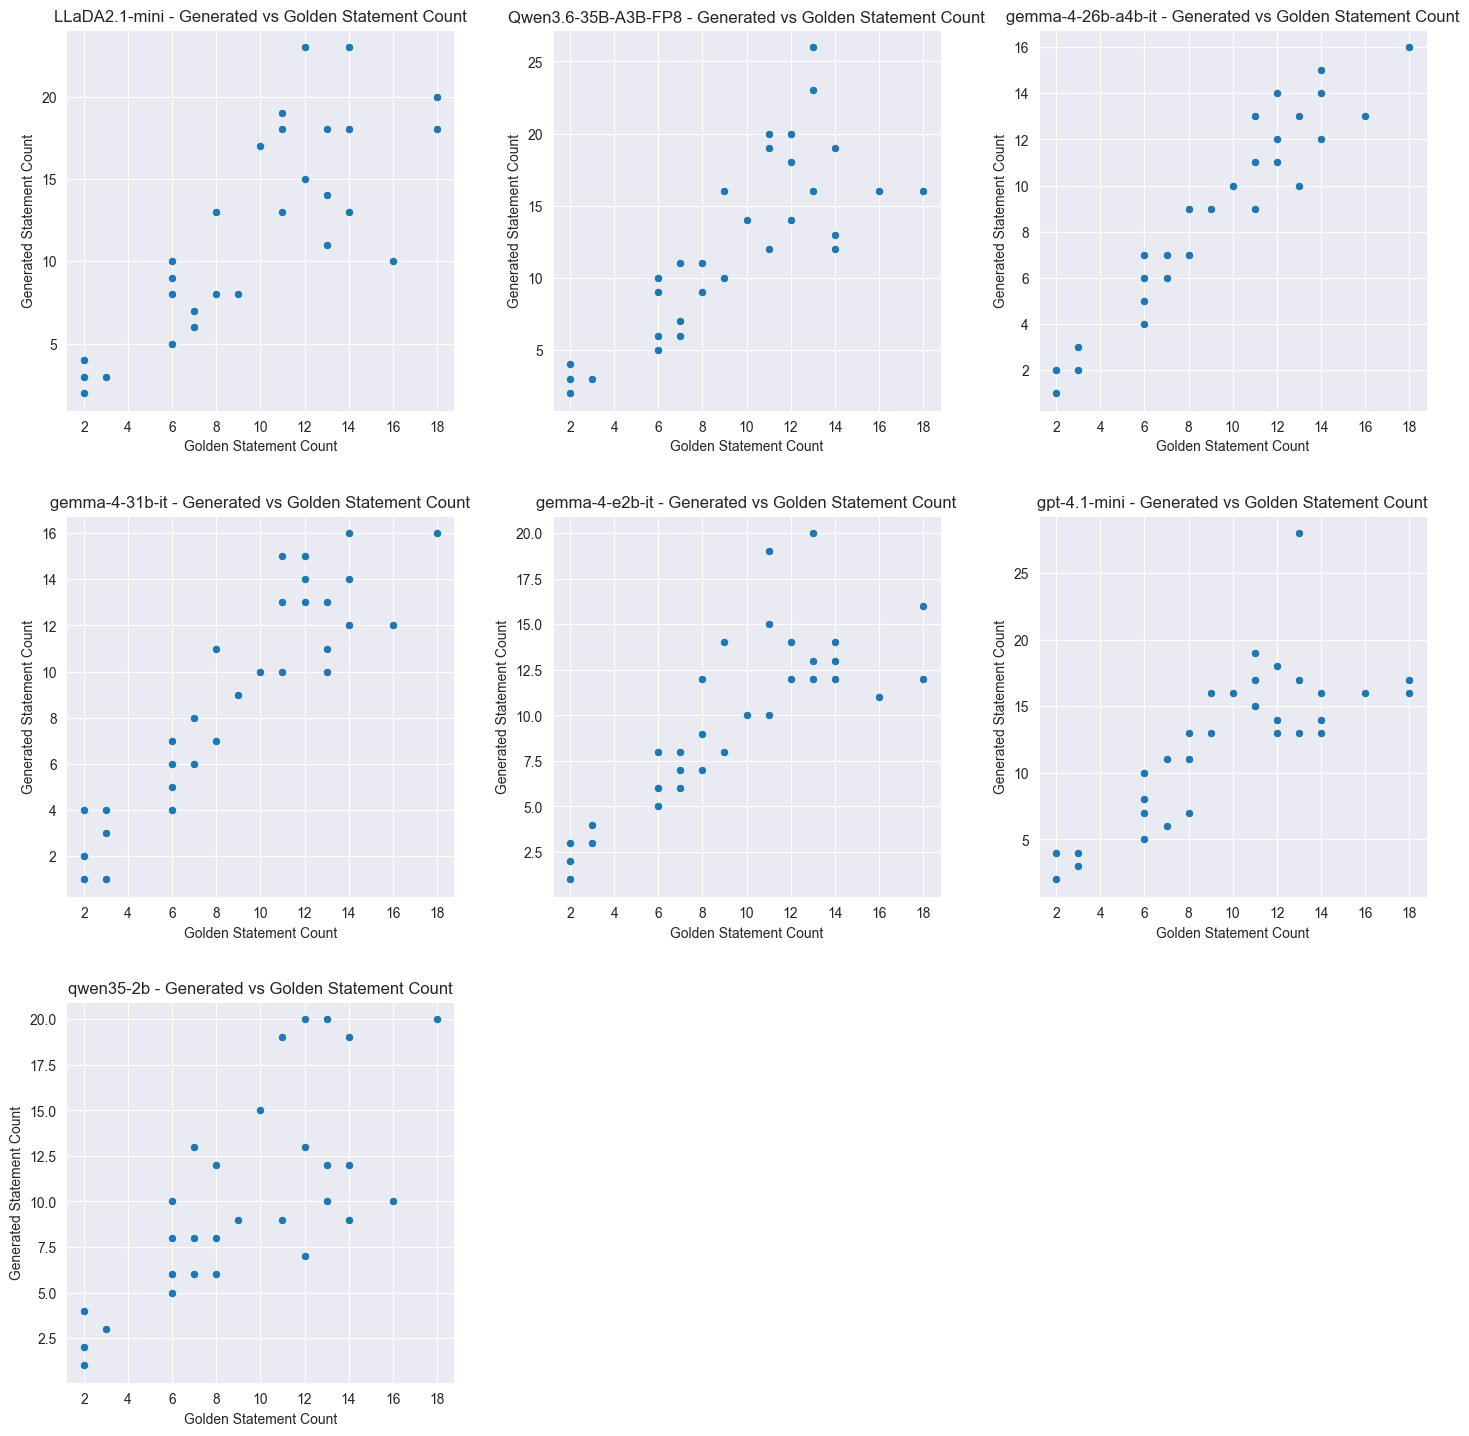

In [26]:
# lets plot a scatter plot of statements count of each model vs golden (to see if they are connected)

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

for i, model in enumerate(ft_exp1.index.get_level_values('model').unique()):
    plt.subplot(3, 3, i + 1)
    df = ft_exp1.loc[model].join(golden_counts_s, how='inner')
    sns.scatterplot(
        x='golden_count',
        y='gen_count',
        data=df
    )
    plt.title(f"{model} - Generated vs Golden Statement Count")
    plt.xlabel("Golden Statement Count")
    plt.ylabel("Generated Statement Count")

plt.tight_layout(pad=3.0)
plt.show()


In [27]:
# lets calculate mean and range of count of statements for each model, grouped by granularity (LOW/MEDIUM/HIGH) based on case description in ft_golden_descriptions

granularity_groups = {'LOW': [], 'MEDIUM': [], 'HIGH': []}

for cid, desc in ft_golden_descriptions.items():
    if 'low' in desc.lower():
        granularity_groups['LOW'].append(cid)
    elif 'medium' in desc.lower():
        granularity_groups['MEDIUM'].append(cid)
    elif 'high' in desc.lower():
        granularity_groups['HIGH'].append(cid)

# for each model, calculate mean and range of generated statement count for cases in each granularity group
# place the data in a df, and calculate the data for the golden dataset as well

ft_exp1_count_means = []
for model in ft_exp1.index.get_level_values('model').unique():
    df = ft_exp1.loc[model].join(golden_counts_s, how='inner')
    print(f"Model: {model}")
    for granularity, cids in granularity_groups.items():
        group_df = df[df.index.isin(cids)]
        mean_count = group_df['gen_count'].mean()
        min_count = group_df['gen_count'].min()
        max_count = group_df['gen_count'].max()

        ft_exp1_count_means.append({
            'model': model,
            'granularity': granularity,
            'mean_gen_count': round(mean_count, 1) if not pd.isna(mean_count) else None,
            'min_gen_count': int(min_count),
            'max_gen_count': int(max_count),
        })

ft_exp1_count_means_df = pd.DataFrame(ft_exp1_count_means)


golden_count_means = []
for granularity, cids in granularity_groups.items():
    df = golden_counts_s[golden_counts_s.index.isin(cids)]
    mean_count = df.mean()
    min_count = df.min()
    max_count = df.max()
    golden_count_means.append({
        'granularity': granularity,
        'mean_golden_count': round(mean_count, 1) if not pd.isna(mean_count) else None,
        'min_golden_count': int(min_count),
        'max_golden_count': int(max_count),
    })
golden_count_means_df = pd.DataFrame(golden_count_means)

# now join this so we have a table with model, granularity, mean_gen_count, min_gen_count, max_gen_count, mean_golden_count, min_golden_count, max_golden_count
ft_exp1_count_means_df = ft_exp1_count_means_df.join(golden_count_means_df.set_index('granularity'), on='granularity')
ft_exp1_count_means_df.to_csv(BASE / "results" / "faithfulness_exp1_statement_count_by_granularity.csv", index=False)
ft_exp1_count_means_df

Model: LLaDA2.1-mini
Model: Qwen3.6-35B-A3B-FP8
Model: gemma-4-26b-a4b-it
Model: gemma-4-31b-it
Model: gemma-4-e2b-it
Model: gpt-4.1-mini
Model: qwen35-2b


,model,granularity,mean_gen_count,min_gen_count,max_gen_count,mean_golden_count,min_golden_count,max_golden_count
0,LLaDA2.1-mini,LOW,2.8,2,4,2.3,2,3
1,LLaDA2.1-mini,MEDIUM,8.7,5,15,7.6,6,12
2,LLaDA2.1-mini,HIGH,16.9,10,23,13.2,9,18
3,Qwen3.6-35B-A3B-FP8,LOW,2.5,2,4,2.3,2,3
4,Qwen3.6-35B-A3B-FP8,MEDIUM,9.1,5,14,7.6,6,12
5,Qwen3.6-35B-A3B-FP8,HIGH,17.6,12,26,13.2,9,18
6,gemma-4-26b-a4b-it,LOW,2.1,1,3,2.3,2,3
7,gemma-4-26b-a4b-it,MEDIUM,6.9,4,11,7.6,6,12
8,gemma-4-26b-a4b-it,HIGH,12.5,9,16,13.2,9,18
9,gemma-4-31b-it,LOW,2.1,1,4,2.3,2,3


In [28]:
# --- Compute faithfulness metrics ---
ft_rows = []

for model in sorted(ft_exp1.index.get_level_values('model').unique()):
    row = {'model': model}
    
    # --- Exp 1: statement count granularity ---
    e1 = ft_exp1.loc[model]
    e1 = e1.join(golden_counts_s, how='inner')
    if len(e1) > 0 and e1['gen_count'].notna().sum() > 1:
        row['exp1_mae'] = mean_absolute_error(
            e1['golden_count'].fillna(0).astype(int),
            e1['gen_count'].fillna(0).astype(int)
        )
    
    # --- Exp 2: continuous score ---
    e2 = ft_exp2.loc[model].join(ft_golden_scores_s, how='inner')
    if len(e2) > 0 and e2['score'].notna().sum() > 1:
        sc = report_continuous('exp2', e2['golden_score'], e2['score'])
        row.update(sc)
    
    # --- Exp 2: per-statement binary verdicts ---
    stmt_rows = []
    for _, r in e2.iterrows():
        if pd.isna(r.get('total_count', 0)):
            continue
        for si in range(int(r['total_count'])):
            col = f'statement_{si}_verdict'
            if col in r.index and pd.notna(r[col]):
                stmt_rows.append({
                    'case_id': r.name,
                    'statement_idx': si,
                    'predicted': int(r[col]),
                })
    
    if stmt_rows:
        stmt_df = pd.DataFrame(stmt_rows).set_index(['case_id', 'statement_idx'])
        merged = stmt_df.join(ft_golden_verdicts_df, how='inner')
        if len(merged) > 0:
            bin_ = report_binary('exp2_verdict', merged['verdict'], merged['predicted'])
            row.update(bin_)
    
    ft_rows.append(row)

ft_metrics = pd.DataFrame(ft_rows).set_index('model')
ft_metrics

,exp1_mae,exp2_mae,exp2_pearson_r,exp2_spearman_rho,exp2_verdict_accuracy,exp2_verdict_f1
model,,,,,,
LLaDA2.1-mini,2.622222,0.021195,0.989445,0.984222,0.965079,0.968839
Qwen3.6-35B-A3B-FP8,2.444444,0.001852,0.999571,0.999786,0.997110,0.997455
gemma-4-26b-a4b-it,0.800000,0.003561,0.999188,0.998362,0.994220,0.994924
gemma-4-31b-it,1.155556,0.003561,0.999188,0.998362,0.994220,0.994924
gemma-4-e2b-it,1.466667,0.045349,0.968066,0.963482,0.953757,0.960784
gpt-4.1-mini,2.288889,0.001709,0.999635,0.998576,0.997110,0.997468
qwen35-2b,2.333333,0.053890,0.906667,0.886138,0.930636,0.941176


---
## Summary Table

Collects all metrics across all models into one DataFrame.

In [29]:
# Combine all metric tables
summary_parts = []

# AR
ar_flat = ar_metrics.copy()
ar_flat.columns = [f"ar_{c}" for c in ar_flat.columns]
summary_parts.append(ar_flat)

# CR - select avg judge columns and combined columns
cr_cols = [c for c in cr_metrics.columns if 'avg_judge' in c or c.startswith('combined')]
if not cr_cols:
    cr_cols = list(cr_metrics.columns)
cr_flat = cr_metrics[cr_cols].copy()
cr_flat.columns = [f"cr_{c}" for c in cr_flat.columns]
summary_parts.append(cr_flat)

# RG - same logic
rg_cols = [c for c in rg_metrics.columns if 'avg_judge' in c or c.startswith('combined')]
if not rg_cols:
    rg_cols = list(rg_metrics.columns)
rg_flat = rg_metrics[rg_cols].copy()
rg_flat.columns = [f"rg_{c}" for c in rg_flat.columns]
summary_parts.append(rg_flat)

# CU
cu_flat = cu_metrics.copy()
cu_flat.columns = [f"cu_{c}" for c in cu_flat.columns]
summary_parts.append(cu_flat)

# FT
ft_flat = ft_metrics.copy()
ft_flat.columns = [f"ft_{c}" for c in ft_flat.columns]
summary_parts.append(ft_flat)

summary = pd.concat(summary_parts, axis=1)

# Round for display
summary_display = summary.map(lambda x: round(x, 4) if isinstance(x, float) else x)
summary_display

,ar_score_mae,ar_score_pearson_r,ar_score_spearman_rho,ar_noncommittal_accuracy,ar_noncommittal_f1,ar_noncommittal_weighted_f1,ar_noncommittal_macro_f1,cr_combined_mae,cr_combined_pearson_r,cr_combined_spearman_rho,...,cu_per_chunk_f1,cu_final_mae,cu_final_pearson_r,cu_final_spearman_rho,ft_exp1_mae,ft_exp2_mae,ft_exp2_pearson_r,ft_exp2_spearman_rho,ft_exp2_verdict_accuracy,ft_exp2_verdict_f1
model,,,,,,,,,,,,,,,,,,,,,
LLaDA2.1-mini,0.0628,0.9321,0.8737,1.00,0.0,1.0000,1.0000,0.1310,0.7716,0.7650,...,0.3448,0.3068,-0.2726,-0.2613,2.6222,0.0212,0.9894,0.9842,0.9651,0.9688
Qwen3.6-35B-A3B-FP8,0.0482,0.9478,0.9398,0.95,0.0,0.9744,0.4872,0.0536,0.9469,0.9602,...,0.8636,0.3864,0.4053,0.3780,2.4444,0.0019,0.9996,0.9998,0.9971,0.9975
gemma-4-26b-a4b-it,0.0608,0.9378,0.9308,0.95,0.0,0.9744,0.4872,0.0298,0.9619,0.9644,...,0.6552,0.4091,0.6547,0.5570,0.8000,0.0036,0.9992,0.9984,0.9942,0.9949
gemma-4-31b-it,0.0690,0.9282,0.9218,0.95,0.0,0.9744,0.4872,0.0833,0.9186,0.9410,...,0.7755,0.4091,0.6547,0.6738,1.1556,0.0036,0.9992,0.9984,0.9942,0.9949
gemma-4-e2b-it,0.0482,0.9690,0.9353,1.00,0.0,1.0000,1.0000,0.1369,0.8673,0.8574,...,0.7143,0.3864,0.2978,0.2349,1.4667,0.0453,0.9681,0.9635,0.9538,0.9608
gpt-4.1-mini,0.0892,0.8929,0.8496,0.95,0.0,0.9744,0.4872,0.0595,0.9348,0.9348,...,0.9048,0.3864,0.4053,0.3986,2.2889,0.0017,0.9996,0.9986,0.9971,0.9975
qwen35-2b,0.0792,0.9038,0.8481,0.95,0.0,0.9744,0.4872,0.1964,0.7268,0.6899,...,0.8372,0.3864,0.4111,0.4099,2.3333,0.0539,0.9067,0.8861,0.9306,0.9412


In [30]:
# Save to CSV
out_path = BASE / "results" / "metrics_summary.csv"
summary.to_csv(out_path)
print(f"Summary saved to {out_path}")

Summary saved to /Users/lokovacic/Projects/diffusion-llms-eval/results/metrics_summary.csv
